In [1]:
#Import Libs
from matplotlib import pyplot as plot
import matplotlib as mpl
import urllib.request
import urllib.parse
import numpy as np
import math
import cv2

In [2]:
#URL Image
image_url = 'https://raw.githubusercontent.com/jrafa1607/Computational-Vision-In-Python/main/-%20Images/Running.png'

In [3]:
#Open the Image
with urllib.request.urlopen(image_url) as url:
    s = url.read()

In [4]:
#Convert to a Numpy Array and Decode with cv2
img = cv2.imdecode(np.frombuffer(s, np.uint8), -1)

In [5]:
#Convert from BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

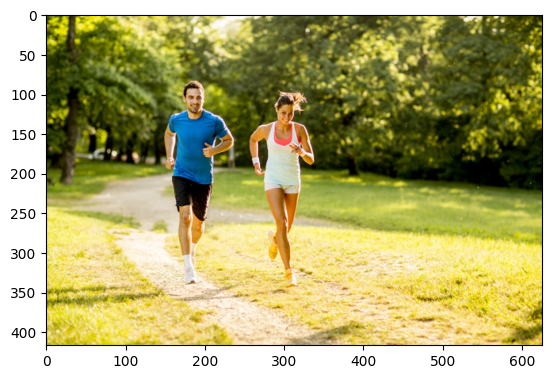

In [6]:
#Show the Image
plot.imshow(img,cmap='gray')
plot.show()

In [7]:
#Convert from RGB to GrayScale
img_gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

### Histogram of Oriented Gradients (HOG)

**HOG** is a feature descriptor used in computer vision and image processing for object detection. It describes the appearance of a local object by the distribution of intensity gradients or edge directions. Here's how it generally works:

1.  **Gradient Computation**: The first step is to calculate the gradient (magnitude and orientation) for each pixel in the image. Gradients are essential because the magnitude is large around edges and corners, and the orientation indicates the direction of intensity change.

2.  **Cell Division**: The image is divided into small connected regions called "cells." For each cell, a histogram of gradient directions is compiled. Each pixel within the cell votes for an orientation bin based on its gradient orientation and magnitude.

3.  **Block Normalization**: To account for variations in illumination and contrast, the local histograms are contrast-normalized. This is done by grouping the cells into larger, overlapping blocks and normalizing the histograms within each block. This normalization process improves the detector's robustness to illumination changes.

4.  **HOG Feature Vector**: All the normalized histograms from all blocks are concatenated into a single feature vector, which represents the HOG descriptor for that image or image region.

5. **HOG with Support Vector Machine (SVM):** HOG descriptors are typically used in conjunction with a machine learning classifier, most commonly a Support Vector Machine (SVM), for object detection. The process is as follows: **Training** and **Detection**.

In [8]:
#HOG Descriptor Selection
hog = cv2.HOGDescriptor()

In [9]:
#Define the SVM Detector
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

In [10]:
#Create the Voxes for Detection
boxes, weights = hog.detectMultiScale(img_gray)

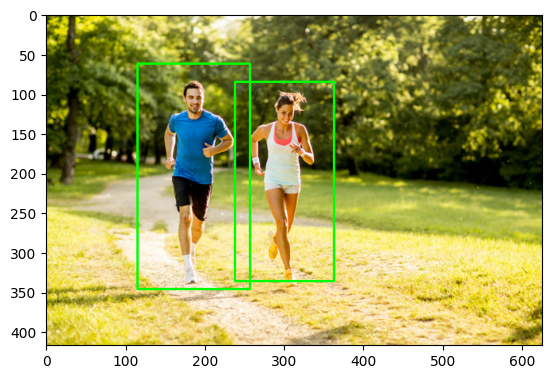

In [11]:
#Make the Classification
for (x, y, w, h) in boxes:

    LeftUpper = (x, y)
    RightLower = (x + w, y + h)
    color = (0, 255, 0)
    width = 2

    cv2.rectangle(img, LeftUpper, RightLower, color, width)

plot.imshow(img,cmap='gray')
plot.show()